In [1]:
# Cell 1: Install and Import Required Libraries
!pip install tensorflow opencv-python tf-keras

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from zipfile import ZipFile
import matplotlib.pyplot as plt
import cv2
import string
import re

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.5 MB/s eta 0:00:00


In [2]:
# Cell 2: Download Dataset
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d adityajn105/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0


In [3]:
# Cell 3: Unzip and Load Captions
with ZipFile("/content/flickr8k.zip", 'r') as zip_ref:
    zip_ref.extractall()

captions_path = '/content/captions.txt'
data = pd.read_csv(captions_path)
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [4]:
# Cell 4: Clean Captions
def clean_caption(caption):
    caption = caption.lower()
    caption = caption.translate(str.maketrans('', '', string.punctuation))
    caption = re.sub(r'\d+', '', caption)
    caption = re.sub(r'\s+', ' ', caption).strip()
    return caption

data['cleaned_caption'] = data['caption'].apply(clean_caption)
data['cleaned_caption'] = 'startseq ' + data['cleaned_caption'] + ' endseq'

In [5]:
# Cell 5: Load and Extract Image Features
xception_model = Xception(include_top=False, weights='imagenet', input_shape=(299, 299, 3))
xception_model.trainable = False

model_input = xception_model.input
model_output = tf.keras.layers.GlobalAveragePooling2D()(xception_model.output)
feature_extractor = Model(inputs=model_input, outputs=model_output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
from tqdm import tqdm
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input

image_folder = '/content/Images'
image_features = {}

# Step 1: Extract features for unique images only
unique_images = data['image'].unique()

for img_name in tqdm(unique_images, desc="Extracting features"):
    path = os.path.join(image_folder, img_name)
    if os.path.exists(path):
        img = load_img(path, target_size=(299, 299))
        img = img_to_array(img)
        img = preprocess_input(img)
        img = np.expand_dims(img, axis=0)
        feature = feature_extractor.predict(img, verbose=0)
        image_features[img_name] = feature.reshape(2048)
    else:
        print(f"⚠️ Missing file: {img_name}")

# Step 2: Align features with all captions (repeat features as needed)
all_image_features = np.array([
    image_features[img_name] for img_name in data['image']
])  # This matches shape with captions

print("✅ Final shape of image features:", all_image_features.shape)


Extracting features: 100%|██████████| 8091/8091 [1:36:16<00:00,  1.40it/s]

✅ Final shape of image features: (40455, 2048)


In [7]:
# Cell 7: Prepare Data Mappings
captions_dict = {}
for idx, row in data.iterrows():
    img, caption = row['image'], row['cleaned_caption']
    captions_dict.setdefault(img, []).append(caption)

In [8]:
# Cell 8: Tokenizer and Max Length
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['cleaned_caption'])

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in data['cleaned_caption'])

In [9]:
# Cell 8: Train/Val Split
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(data, test_size=0.15, random_state=42)

def build_caption_dict(df):
    cap_dict = {}
    for idx, row in df.iterrows():
        cap_dict.setdefault(row['image'], []).append(row['cleaned_caption'])
    return cap_dict

train_captions = build_caption_dict(train_data)
val_captions = build_caption_dict(val_data)

In [10]:
# Cell 9: Data Generators
def data_generator(captions_dict, image_features, batch_size):
    X1, X2, y = [], [], []
    while True:
        for img_name, caps in captions_dict.items():
            img_feat = image_features[img_name]
            for cap in caps:
                seq = tokenizer.texts_to_sequences([cap])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = tf.keras.utils.to_categorical([out_seq], num_classes=vocab_size)[0]
                    X1.append(img_feat)
                    X2.append(in_seq)
                    y.append(out_seq)
                    if len(X1) == batch_size:
                        yield (np.array(X1), np.array(X2)), np.array(y)
                        X1, X2, y = [], [], []

In [11]:
# Cell 10: Define Model
# Image input
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Text input
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

# Decoder (merge)
decoder1 = Add()([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 37, 256)   │  2,247,936 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 37, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 37)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8781)      │  2,256,717 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,620,301 (21.44 MB)

 Trainable params: 5,620,301 (21.44 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Cell 11: Train Model
batch_size = 64
train_steps = sum(len(v) for v in train_captions.values()) // batch_size
val_steps = sum(len(v) for v in val_captions.values()) // batch_size

def wrap_generator(captions_dict, image_features, batch_size):
    return tf.data.Dataset.from_generator(
        lambda: data_generator(captions_dict, image_features, batch_size),
        output_signature=(
            (
                tf.TensorSpec(shape=(None, 2048), dtype=tf.float32),
                tf.TensorSpec(shape=(None, max_length), dtype=tf.int32)
            ),
            tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32)
        )
    )

train_dataset = wrap_generator(train_captions, image_features, batch_size)
val_dataset = wrap_generator(val_captions, image_features, batch_size)

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

model.fit(
    train_dataset,
    epochs=10,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=callbacks
)

Epoch 1/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - loss: 5.8950

537/537 ━━━━━━━━━━━━━━━━━━━━ 304s 562ms/step - loss: 5.8937 - val_loss: 4.3801
Epoch 2/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - loss: 4.4551

537/537 ━━━━━━━━━━━━━━━━━━━━ 300s 559ms/step - loss: 4.4549 - val_loss: 4.0309
Epoch 3/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - loss: 4.1719

537/537 ━━━━━━━━━━━━━━━━━━━━ 301s 560ms/step - loss: 4.1718 - val_loss: 3.8531
Epoch 4/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - loss: 4.0215

537/537 ━━━━━━━━━━━━━━━━━━━━ 301s 560ms/step - loss: 4.0214 - val_loss: 3.7443
Epoch 5/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - loss: 3.8751

...

537/537 ━━━━━━━━━━━━━━━━━━━━ 300s 559ms/step - loss: 3.7807 - val_loss: 3.5657
Epoch 7/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - loss: 3.6754

537/537 ━━━━━━━━━━━━━━━━━━━━ 300s 559ms/step - loss: 3.6754 - val_loss: 3.5060
Epoch 8/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - loss: 3.6591

537/537 ━━━━━━━━━━━━━━━━━━━━ 300s 559ms/step - loss: 3.6590 - val_loss: 3.4495
Epoch 9/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - loss: 3.5575

537/537 ━━━━━━━━━━━━━━━━━━━━ 302s 562ms/step - loss: 3.5575 - val_loss: 3.3891
Epoch 10/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - loss: 3.5467

537/537 ━━━━━━━━━━━━━━━━━━━━ 302s 563ms/step - loss: 3.5467 - val_loss: 3.3635


In [13]:
# Cell 12: Generate Caption
def generate_caption(photo_feature):
    in_text = 'startseq'
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo_feature.reshape((1, 2048)), sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat, None)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text.replace('startseq', '').replace('endseq', '').strip()

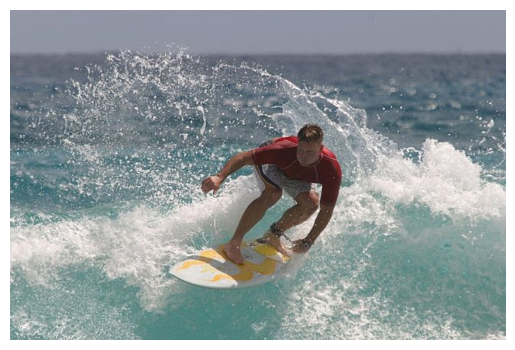

In [20]:
import cv2
from matplotlib import pyplot as plt

# Load image
img = cv2.imread('/content/surf.jpg')

# Convert from BGR (OpenCV default) to RGB (for correct colors)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show the image
plt.imshow(img_rgb)
plt.axis('off')  # Hide axis
plt.show()


In [16]:
# Cell 13: Test on New Image
test_img_path = '/content/surf.jpg'

if os.path.exists(test_img_path):
    img = load_img(test_img_path, target_size=(299, 299))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    # Extract feature using the same feature_extractor used during training
    test_feature = feature_extractor.predict(img, verbose=0).reshape((2048,))

    # Generate and print caption
    caption = generate_caption(test_feature)
    print("Generated caption:", caption)
else:
    print(f"⚠️ File not found: {test_img_path}")


Generated caption: a man is jumping into the water


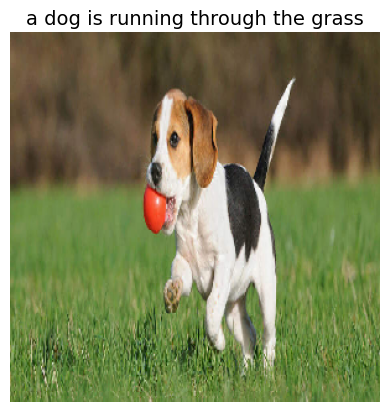

In [23]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

# Test image path
test_img_path = '/content/dog.jpg'

if os.path.exists(test_img_path):
    # Load and preprocess image
    img = load_img(test_img_path, target_size=(299, 299))
    img_array = img_to_array(img)
    img_processed = preprocess_input(img_array)
    img_processed = np.expand_dims(img_processed, axis=0)

    # Extract feature
    test_feature = feature_extractor.predict(img_processed, verbose=0).reshape((2048,))

    # Generate caption
    caption = generate_caption(test_feature)

    # Show image and caption
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption, fontsize=14, wrap=True)
    plt.show()

else:
    print(f"⚠️ File not found: {test_img_path}")


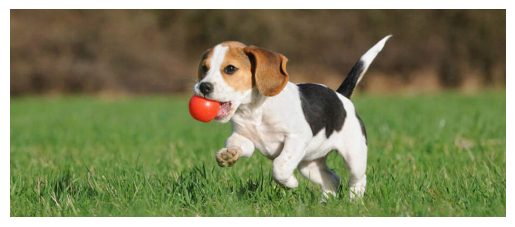

In [21]:
import cv2
from matplotlib import pyplot as plt

# Load image
img = cv2.imread('/content/dog.jpg')

# Convert from BGR (OpenCV default) to RGB (for correct colors)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show the image
plt.imshow(img_rgb)
plt.axis('off')  # Hide axis
plt.show()


In [17]:
# Cell 13: Test on New Image
test_img_path = '/content/dog.jpg'

if os.path.exists(test_img_path):
    img = load_img(test_img_path, target_size=(299, 299))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    # Extract feature using the same feature_extractor used during training
    test_feature = feature_extractor.predict(img, verbose=0).reshape((2048,))

    # Generate and print caption
    caption = generate_caption(test_feature)
    print("Generated caption:", caption)
else:
    print(f"⚠️ File not found: {test_img_path}")


Generated caption: a dog is running through the grass


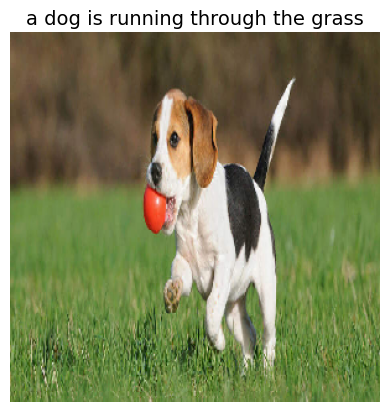

In [22]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

# Test image path
test_img_path = '/content/dog.jpg'

if os.path.exists(test_img_path):
    # Load and preprocess image
    img = load_img(test_img_path, target_size=(299, 299))
    img_array = img_to_array(img)
    img_processed = preprocess_input(img_array)
    img_processed = np.expand_dims(img_processed, axis=0)

    # Extract feature
    test_feature = feature_extractor.predict(img_processed, verbose=0).reshape((2048,))

    # Generate caption
    caption = generate_caption(test_feature)

    # Show image and caption
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption, fontsize=14, wrap=True)
    plt.show()

else:
    print(f"⚠️ File not found: {test_img_path}")


In [30]:
# Cell 13: Test on New Image
test_img_path = '/content/1000268201_693b08cb0e.jpg'

if os.path.exists(test_img_path):
    img = load_img(test_img_path, target_size=(299, 299))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    # Extract feature using the same feature_extractor used during training
    test_feature = feature_extractor.predict(img, verbose=0).reshape((2048,))

    # Generate and print caption
    caption = generate_caption(test_feature)
    print("Generated caption:", caption)
else:
    print(f"⚠️ File not found: {test_img_path}")


Generated caption: a man in a white shirt and a white shirt and a white shirt and a white shirt and a white shirt and a white shirt and a black shirt and a white shirt and a black


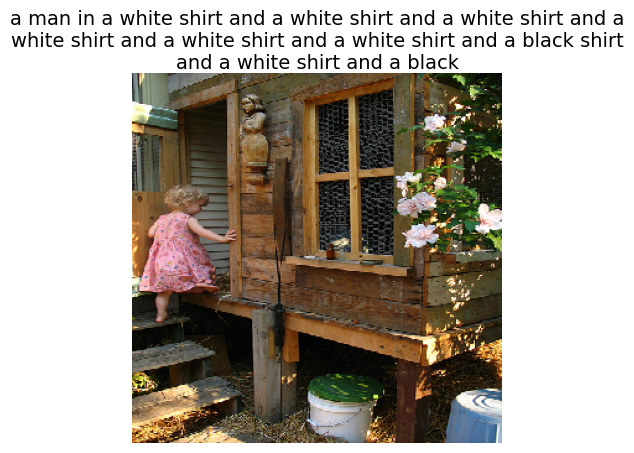

In [29]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

# Test image path
test_img_path = '/content/1000268201_693b08cb0e.jpg'

if os.path.exists(test_img_path):
    # Load and preprocess image
    img = load_img(test_img_path, target_size=(299, 299))
    img_array = img_to_array(img)
    img_processed = preprocess_input(img_array)
    img_processed = np.expand_dims(img_processed, axis=0)

    # Extract feature
    test_feature = feature_extractor.predict(img_processed, verbose=0).reshape((2048,))

    # Generate caption
    caption = generate_caption(test_feature)

    # Show image and caption
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption, fontsize=14, wrap=True)
    plt.show()

else:
    print(f"⚠️ File not found: {test_img_path}")


In [18]:
!pip install nltk

In [36]:
# Download all necessary nltk data
import nltk
nltk.download('popular')  # includes punkt, wordnet, omw-1.4, etc.

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to-date!
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Package names is already up-to-date!
[nltk_data]    | Do

In [37]:
# Define evaluation function
def evaluate_caption(reference_captions, generated_caption):
    # Tokenize
    ref_tokens = [[word.lower() for word in cap.split()] for cap in reference_captions]
    # Tokenize generated_caption before passing to meteor_score
    gen_tokens = [word.lower() for word in generated_caption.split()]

    smoothing = SmoothingFunction().method1

    bleu1 = sentence_bleu(ref_tokens, gen_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothing)
    bleu2 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
    bleu3 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing)
    bleu4 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)

    # Pass tokenized generated_caption to meteor_score
    # The change is here: Tokenize generated_caption before passing it to meteor_score
    #meteor = meteor_score(reference_captions, generated_caption.split()) # Changed line
    meteor = meteor_score([[word.lower() for word in cap.split()] for cap in reference_captions], generated_caption.split()) # Changed line

    return {
        'BLEU-1': bleu1,
        'BLEU-2': bleu2,
        'BLEU-3': bleu3,
        'BLEU-4': bleu4,
        'METEOR': meteor
    }

# Example usage
generated_caption = " a man in a white shirt and a white shirt and a white shirt and a white shirt and a white shirt and a white shirt and a black shirt and a white shirt and a black "
image_id = '1000268201_693b08cb0e'  # without .jpg

# Get references (use .dropna() to avoid NaNs)
reference_captions = data[data['image'].str.lower() == (image_id + '.jpg').lower()]['cleaned_caption'].dropna().tolist()

# Safe check
if reference_captions:
    scores = evaluate_caption(reference_captions, generated_caption)
    print("✅ Evaluation Scores:", scores)
else:
    print(f"⚠️ No reference captions found for image: {image_id}.jpg")

✅ Evaluation Scores: {'BLEU-1': 0.10810810810810814, 'BLEU-2': 0.05479966243511909, 'BLEU-3': 0.021283887186051717, 'BLEU-4': 0.012603820262803964, 'METEOR': 0.1226993865030675}


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import nltk
import os
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

# Ensure 'punkt' is downloaded
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4') # Required for METEOR score calculation

def evaluate_caption(reference_captions, generated_caption):
    """
    reference_captions: list of strings (actual captions for an image)
    generated_caption: string (caption generated by the model)
    """
    # Tokenize using word_tokenize with explicit language
    ref_tokens = [[word.lower() for word in word_tokenize(cap, language='english')] for cap in reference_captions]
    gen_tokens = [word.lower() for word in word_tokenize(generated_caption, language='english')]

    # BLEU Score (using smoothing for short sentences)
    smoothing = SmoothingFunction().method4
    bleu1 = sentence_bleu(ref_tokens, gen_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothing)
    bleu2 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
    bleu3 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing)
    bleu4 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)

    # METEOR Score
    meteor = meteor_score(reference_captions, generated_caption)

    return {
        "BLEU-1": round(bleu1, 4),
        "BLEU-2": round(bleu2, 4),
        "BLEU-3": round(bleu3, 4),
        "BLEU-4": round(bleu4, 4),
        "METEOR": round(meteor, 4)
    }

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
from nltk.tokenize import word_tokenize

# override nltk's default tokenizer if needed
def custom_meteor_score(references, hypothesis):
    references = [word_tokenize(ref.lower()) for ref in references]
    hypothesis = word_tokenize(hypothesis.lower())
    return meteor_score(references, hypothesis)


In [ ]:
generated_caption = "a man in a red shirt is standing on a street"
image_id = 'new'  # example image name (without .jpg)

# Get all reference captions for that image
reference_captions = data[data['image'] == image_id + '.jpg']['cleaned_caption'].tolist()

In [ ]:
custom_meteor_score(reference_captions, generated_caption)

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
generated_caption = "a man in a red shirt is standing on a street"
image_id = 'new'  # example image name (without .jpg)

# Get all reference captions for that image
reference_captions = data[data['image'] == image_id + '.jpg']['cleaned_caption'].tolist()

# Evaluate
scores = evaluate_caption(reference_captions, generated_caption)
print("Evaluation Scores:", scores)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
generated_caption = "a dog is running on the grass"
image_id = 'dog'  # example image name (without .jpg)

# Get all reference captions for that image
reference_captions = data[data['image'] == image_id + '.jpg']['cleaned_caption'].tolist()

# Evaluate
scores = evaluate_caption(reference_captions, generated_caption)
print("Evaluation Scores:", scores)